In [1]:
options(warn = -1)
options(repr.plot.width = 15, repr.plot.height = 9)
Sys.setlocale(category = "LC_ALL",locale = "ko_KR.UTF-8") 

[1] "ko_KR.UTF-8/ko_KR.UTF-8/ko_KR.UTF-8/C/ko_KR.UTF-8/C.UTF-8"

In [2]:
# 단순 회귀 분석
regression <- read.csv("../data/regression.csv")
head(regression)
tail(regression)

,age,Height,Weight
,<chr>,<dbl>,<dbl>
1,0~3Months,59.1,5.9
2,3~6Months,66.7,8.0
3,6~9Months,71.4,8.9
4,9~12Months,75.0,10.1
5,12~18Months,80.1,10.9
6,2Year,87.8,13.2


,age,Height,Weight
,<chr>,<dbl>,<dbl>
26,30~34Year,171.3,71.5
27,35~39Year,170.7,72.3
28,40~49Year,168.6,70.6
29,50~59Year,166.1,69.1
30,60~69Year,164.4,65.9
31,70YearOver,162.4,61.1


In [3]:
str(regression)

'data.frame':	31 obs. of  3 variables:
 $ age   : chr  "0~3Months" "3~6Months" "6~9Months" "9~12Months" ...
 $ Height: num  59.1 66.7 71.4 75 80.1 ...
 $ Weight: num  5.9 8 8.9 10.1 10.9 13.2 14.8 16.7 19.1 21.5 ...


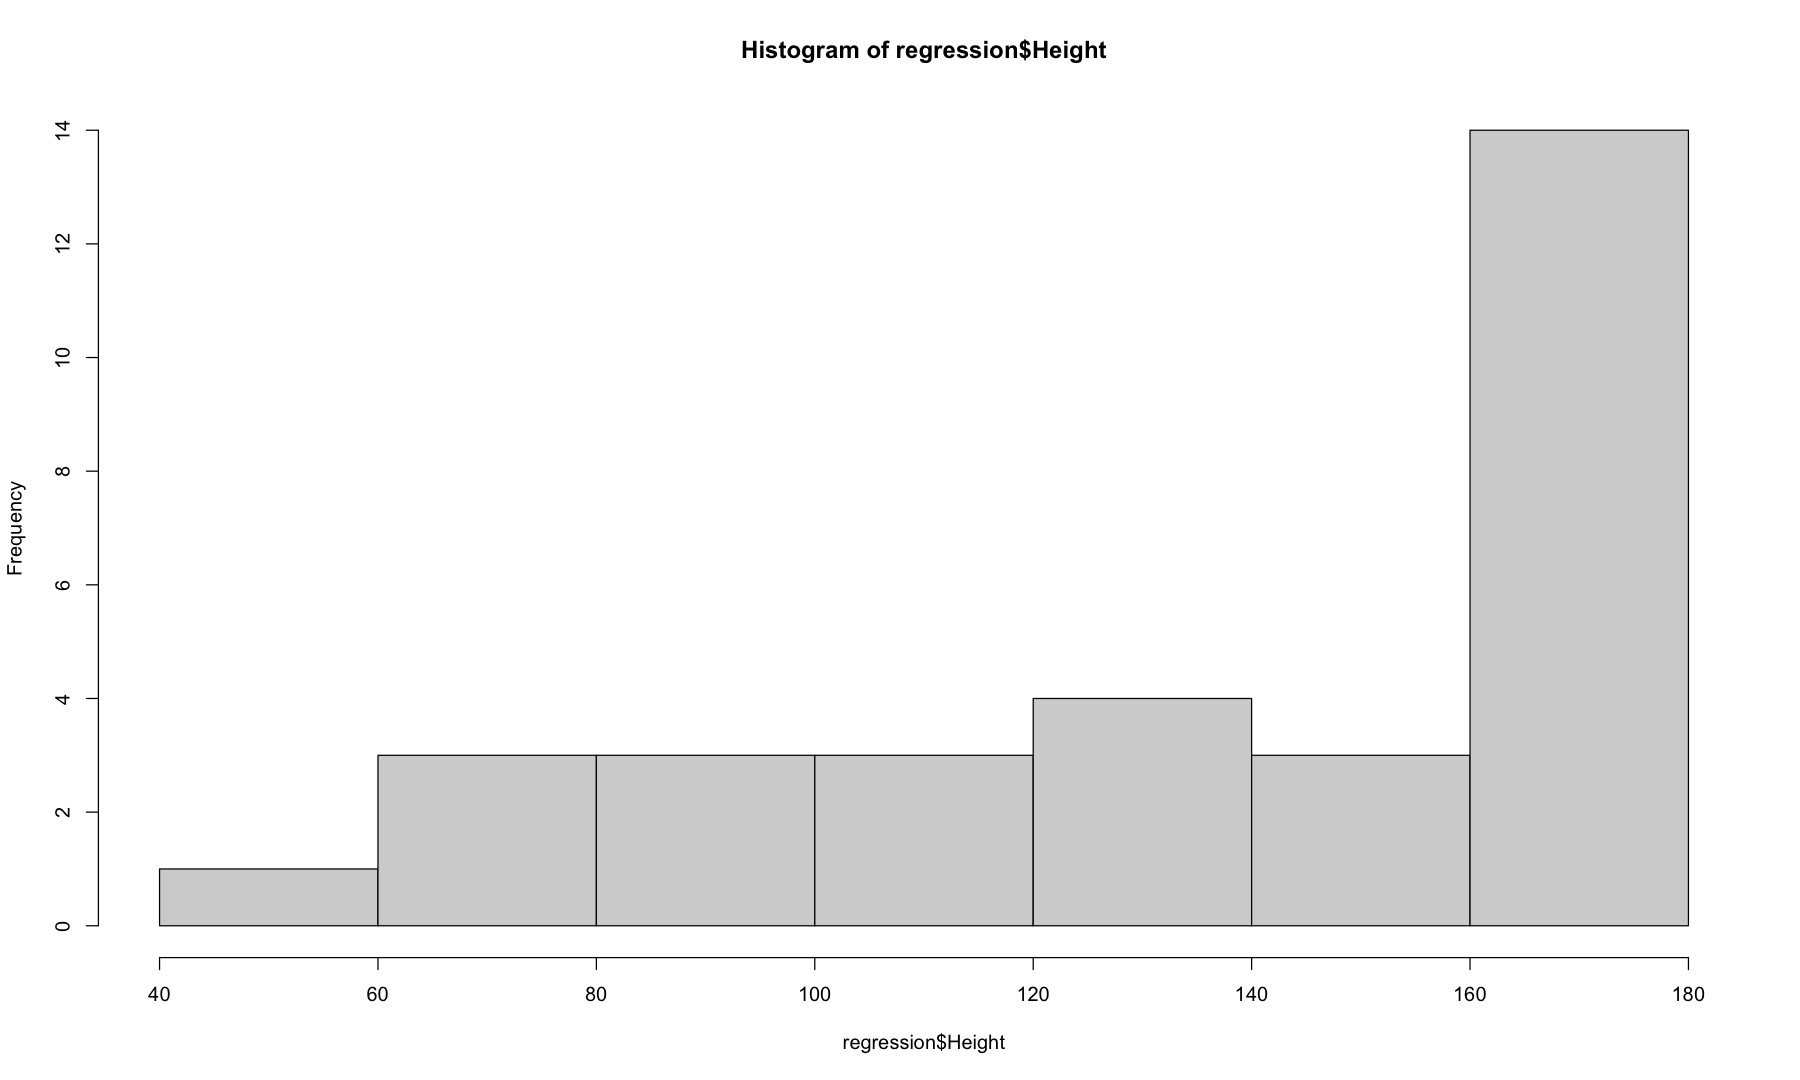

In [6]:
par(bg = "white")
hist(regression$Height)

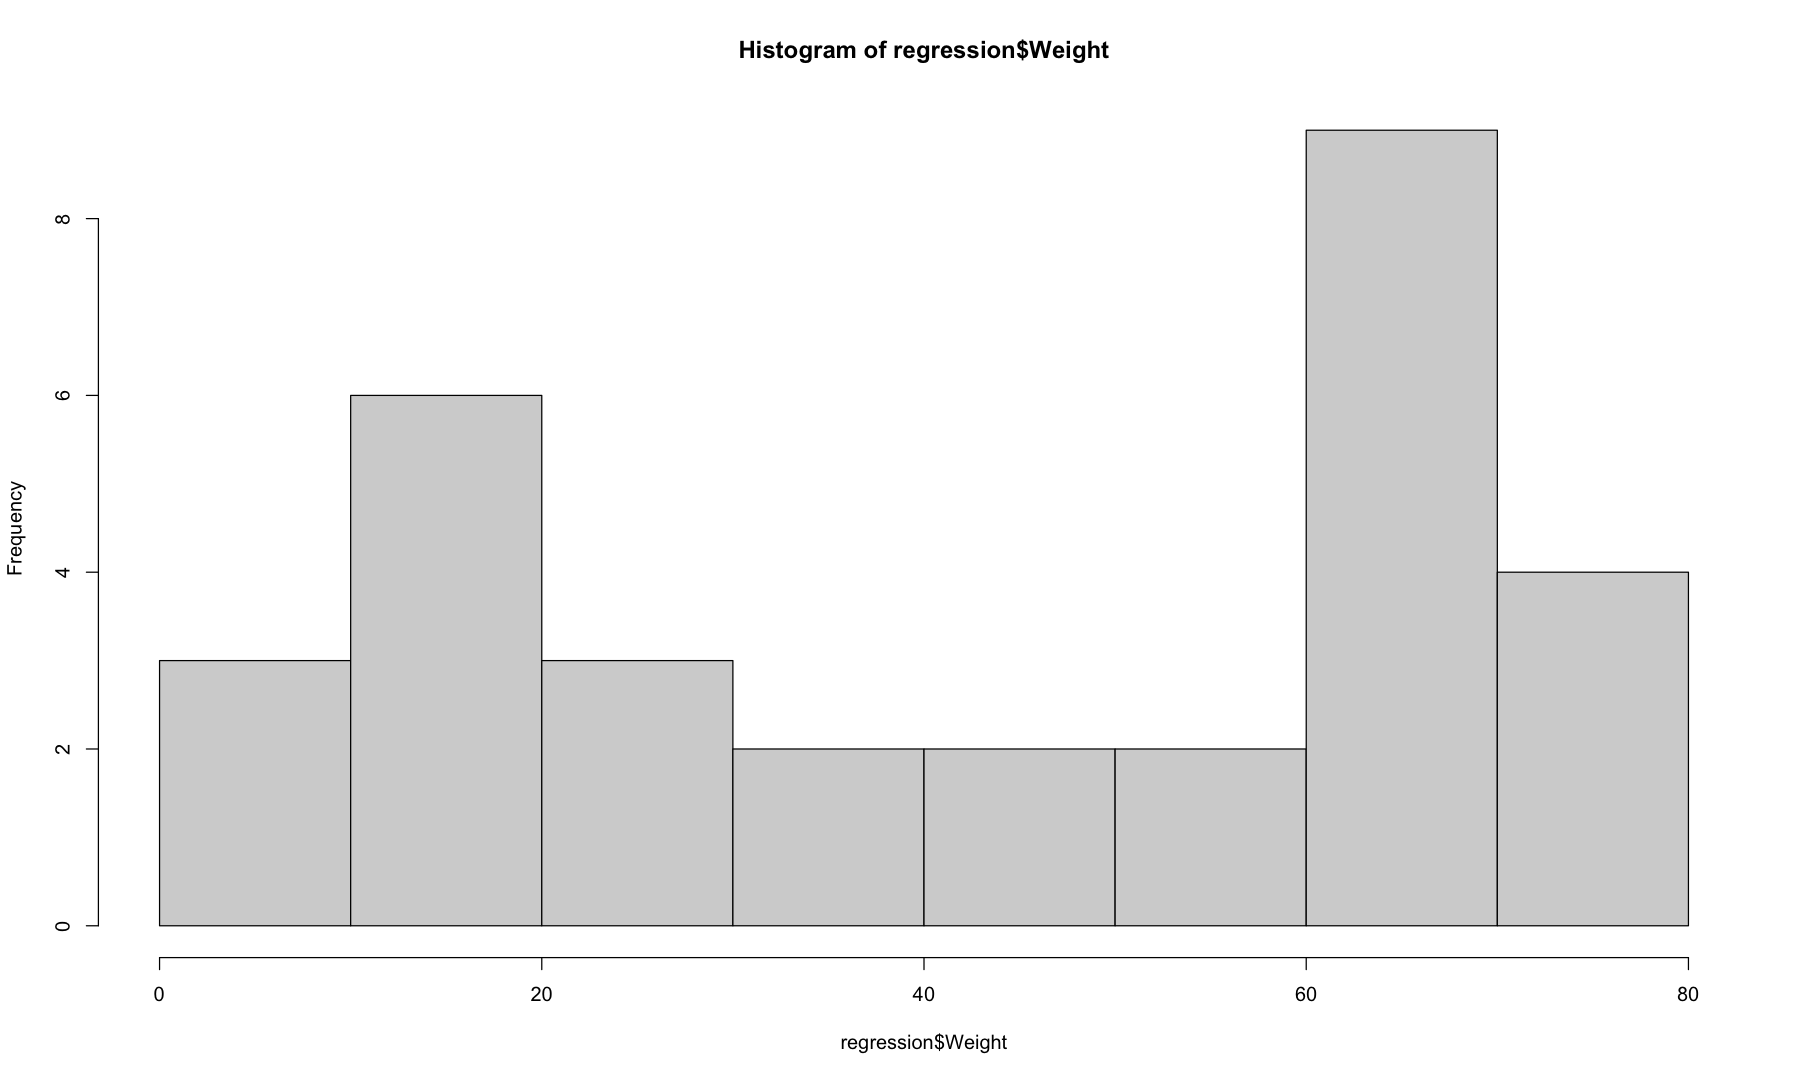

In [7]:
par(bg = "white")
hist(regression$Weight) # 어렸을때 무게, 성인 되었을때 무게

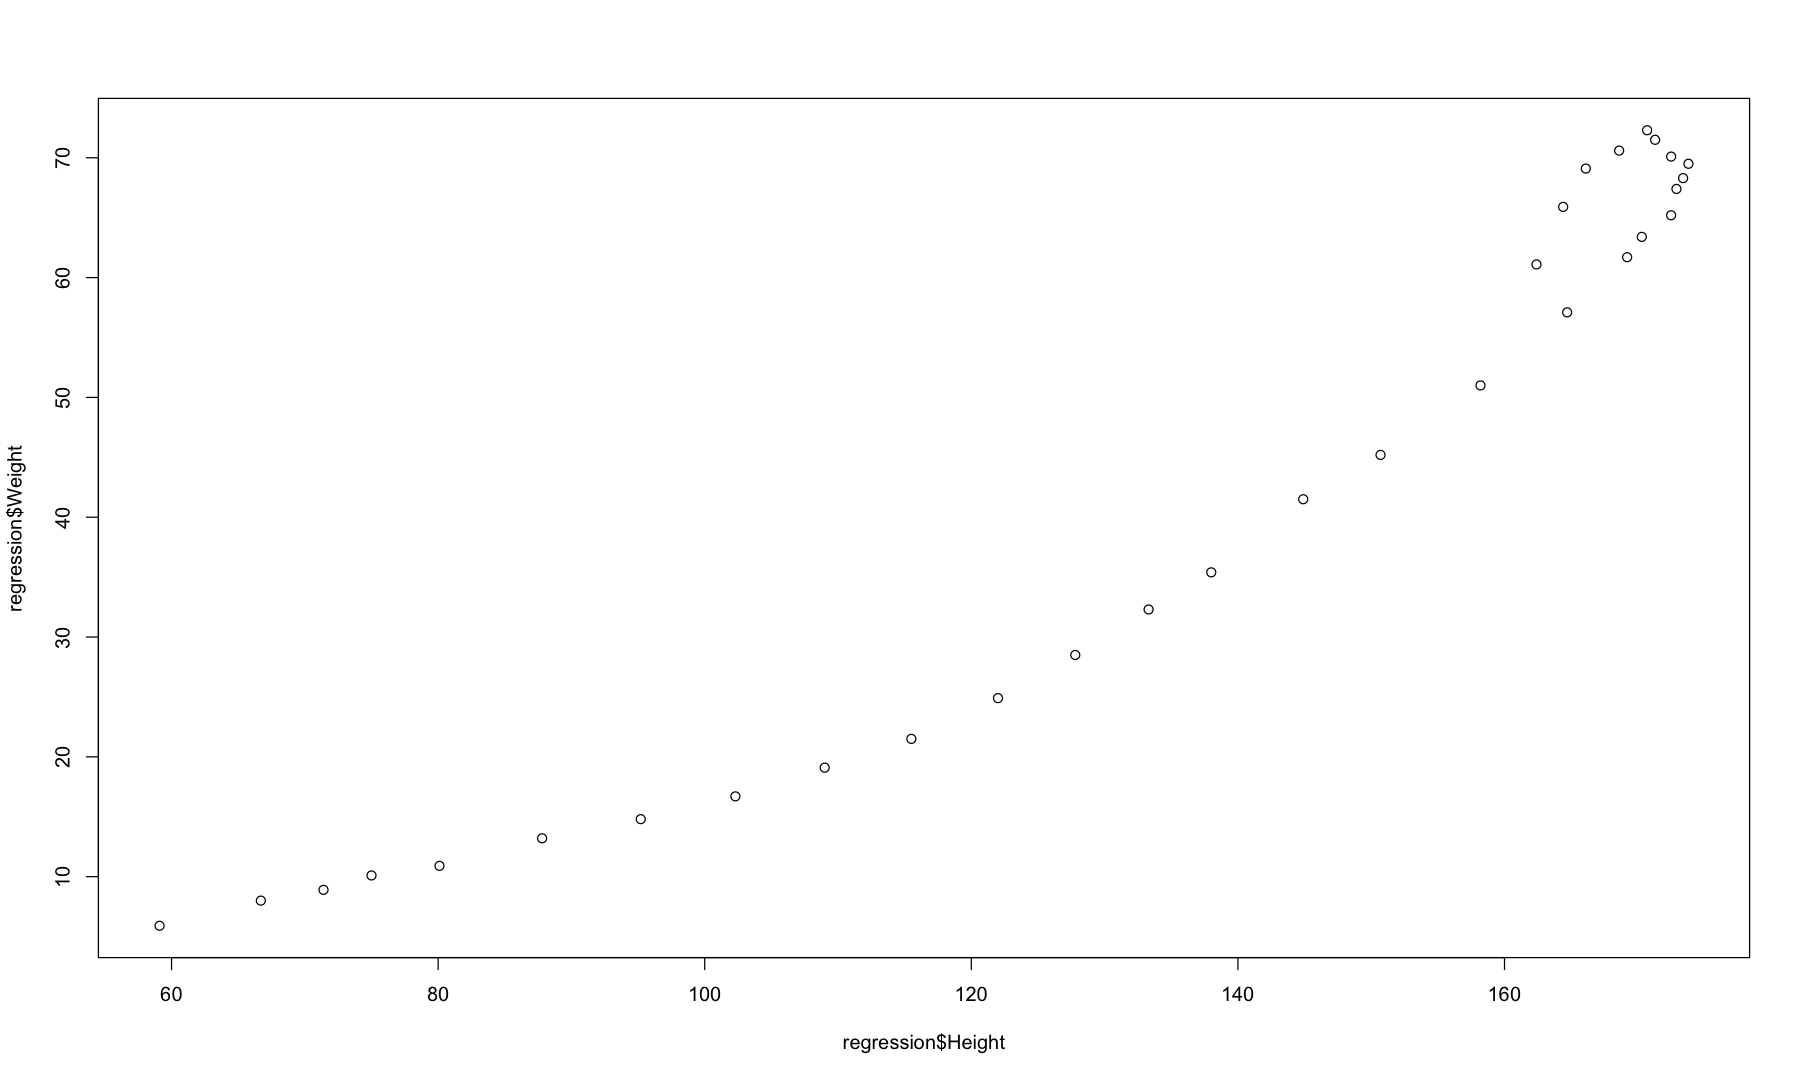

In [8]:
# 이 둘의 산포도 
par(bg = "white")
plot(
    regression$Height, regression$Weight
)

In [9]:
# 상관계수
cor(regression$Height, regression$Weight)

[1] 0.9672103

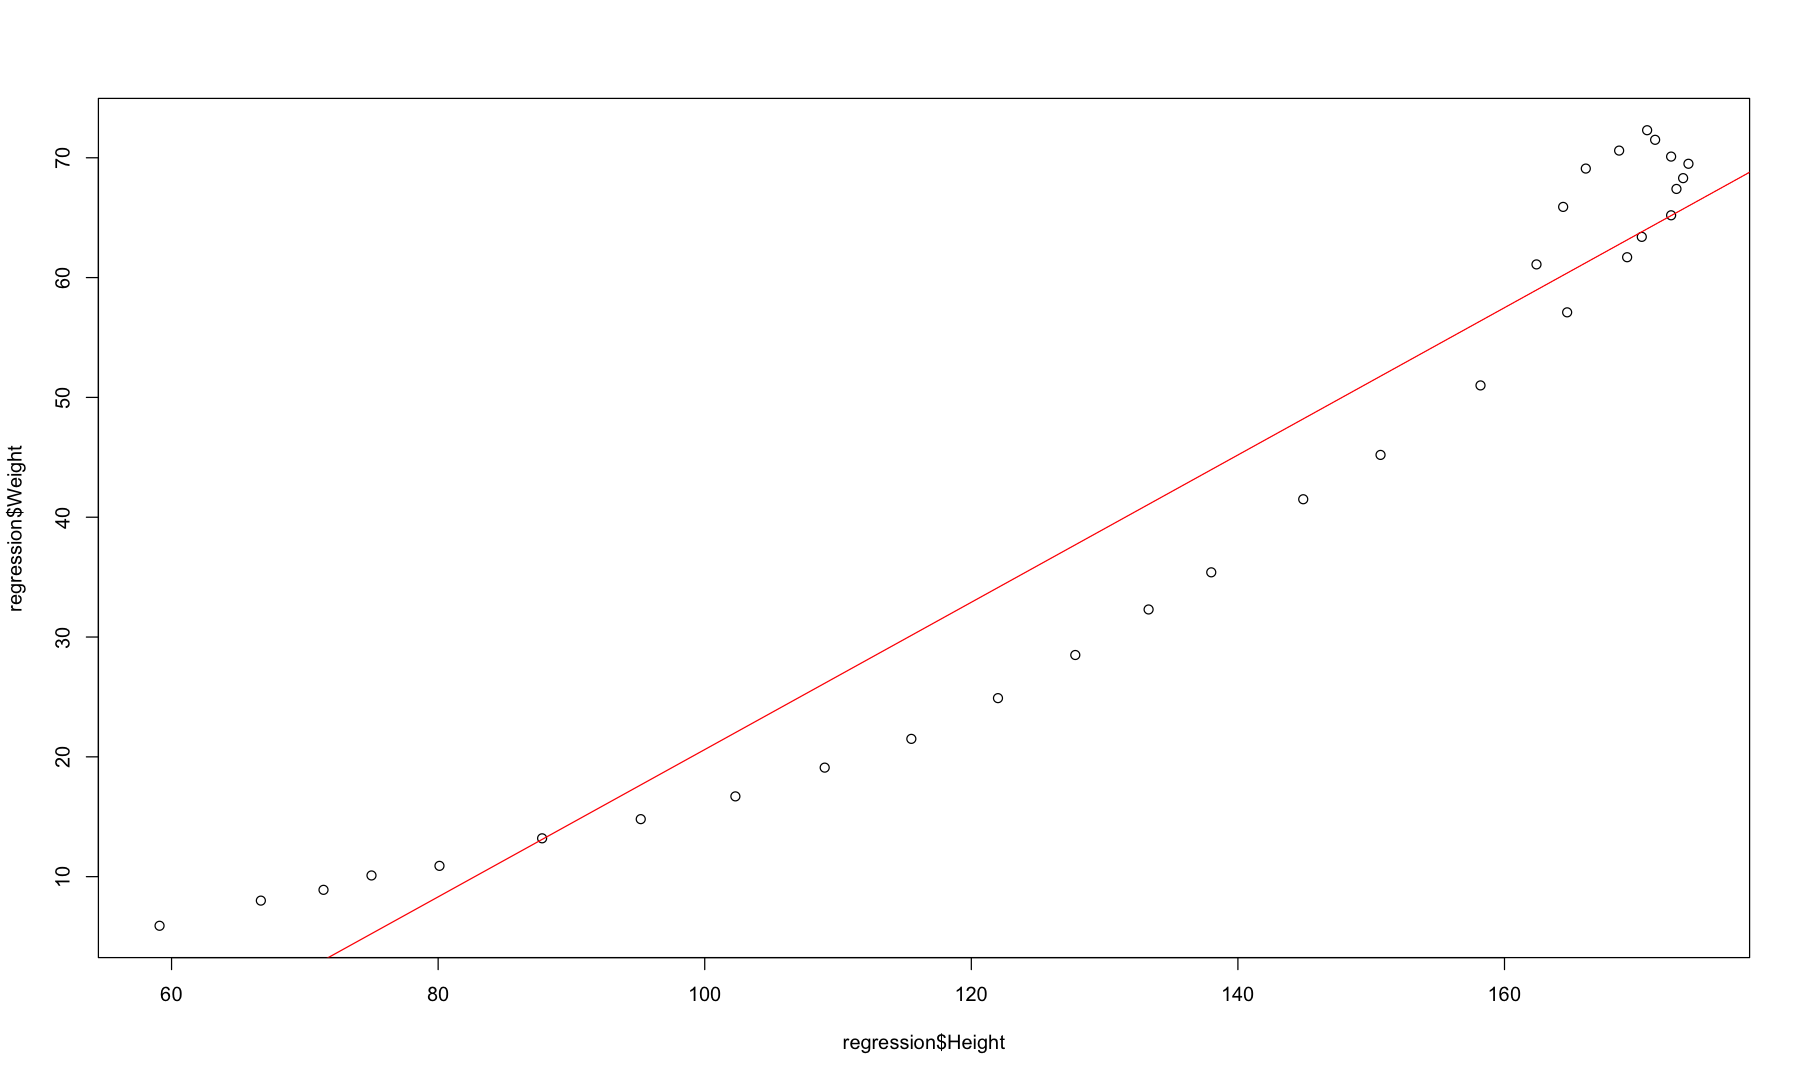

In [10]:
# 이 그래프에 선을 그려보기
par(bg = "white")
plot(
    regression$Height, regression$Weight
)
# 회귀식
r <- lm(regression$Weight ~ regression$Height)
abline(r, col = "red") # r을 추가, 컬러는 레드 _ 추가하는 함수임

In [11]:
# 분석 결과
summary(r)  


Call:
lm(formula = regression$Weight ~ regression$Height)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.2327 -5.9811  0.0915  5.3125 10.4346 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -40.86594    4.22768  -9.666 1.42e-10 ***
regression$Height   0.61474    0.02998  20.508  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.355 on 29 degrees of freedom
Multiple R-squared:  0.9355,	Adjusted R-squared:  0.9333 
F-statistic: 420.6 on 1 and 29 DF,  p-value: < 2.2e-16


p-value: < 2.2e-16 < 0.05       
Intercept(절편) : -40.86594     
regression$Height   0.61474     

weigth = 0.61474 * Height + -40.86594   
Adjusted R-squared:  0.9333      (예측력)


In [12]:
r


Call:
lm(formula = regression$Weight ~ regression$Height)

Coefficients:
      (Intercept)  regression$Height  
         -40.8659             0.6147  


In [14]:
# 키가 170cm인 사람의 몸무게는?
0.6147 * 170 + (-40.8659)

# 표준오차를 적용한 키가 170cm인 사람의 몸무게는?
paste(0.6147 * 170 - 40.8659 - 6.355, "~", 0.6147 * 170 - 40.8659 + 6.355)

[1] 63.6331

[1] "57.2781 ~ 69.9881"

### IQ

In [15]:
iq <- read.csv("../Data/iq.csv")
head(iq)

,이름,성적,IQ,다니는.학원수,게임하는.시간,TV시청.시간
,<chr>,<int>,<int>,<int>,<int>,<int>
1,A,90,140,2,1,0
2,B,75,125,1,3,3
3,C,77,120,1,0,4
4,D,83,135,2,3,2
5,E,65,105,0,4,4
6,F,80,123,3,1,1


In [16]:
str(iq)

'data.frame':	10 obs. of  6 variables:
 $ 이름         : chr  "A" "B" "C" "D" ...
 $ 성적         : int  90 75 77 83 65 80 83 70 87 79
 $ IQ           : int  140 125 120 135 105 123 132 115 128 131
 $ 다니는.학원수: int  2 1 1 2 0 3 3 1 4 2
 $ 게임하는.시간: int  1 3 0 3 4 1 4 1 0 2
 $ TV시청.시간  : int  0 3 4 2 4 1 1 3 0 3


### (1) 성적과 가장 관련이 깊은 항목은?


In [19]:
# 상관계수
cor(iq$성적, iq$IQ)
cor(iq$성적, iq$다니는.학원수)
cor(iq$성적, iq$게임하는.시간)
cor(iq$성적, iq$TV시청.시간)

[1] 0.9102242

[1] 0.7840514

[1] -0.3383549

[1] -0.8473333

In [21]:
# 선생님이 하신 거 
cor(iq[,-1]) # -는 성적이 낮아지는 애들

,성적,IQ,다니는.학원수,게임하는.시간,TV시청.시간
성적,1.0000000,0.9102242,0.7840514,-0.3383549,-0.8473333
IQ,0.9102242,1.0000000,0.6009466,-0.1038108,-0.6783251
다니는.학원수,0.7840514,0.6009466,1.0000000,-0.3106005,-0.8465387
게임하는.시간,-0.3383549,-0.1038108,-0.3106005,1.0000000,0.2440191
TV시청.시간,-0.8473333,-0.6783251,-0.8465387,0.2440191,1.0000000


> 성적과 가장 관계가 깊은 항목은 IQ이다.

#### IQ가 126인 사람의 성적을 예측해보세요

In [22]:
r <- lm(iq$성적 ~ iq$IQ)

In [23]:
r


Call:
lm(formula = iq$성적 ~ iq$IQ)

Coefficients:
(Intercept)        iq$IQ  
    -5.2918       0.6714  


In [24]:
# 분석 결과
summary(r)  


Call:
lm(formula = iq$성적 ~ iq$IQ)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.6598 -2.2384 -0.2674  1.6186  6.3544 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -5.2918    13.5832  -0.390 0.707007    
iq$IQ         0.6714     0.1080   6.217 0.000255 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.322 on 8 degrees of freedom
Multiple R-squared:  0.8285,	Adjusted R-squared:  0.8071 
F-statistic: 38.65 on 1 and 8 DF,  p-value: 0.0002547


In [25]:
r


Call:
lm(formula = iq$성적 ~ iq$IQ)

Coefficients:
(Intercept)        iq$IQ  
    -5.2918       0.6714  


In [26]:
# IQ가 126인 사람의 성적?
0.6714    * 126 + (-5.2918)

[1] 79.3046

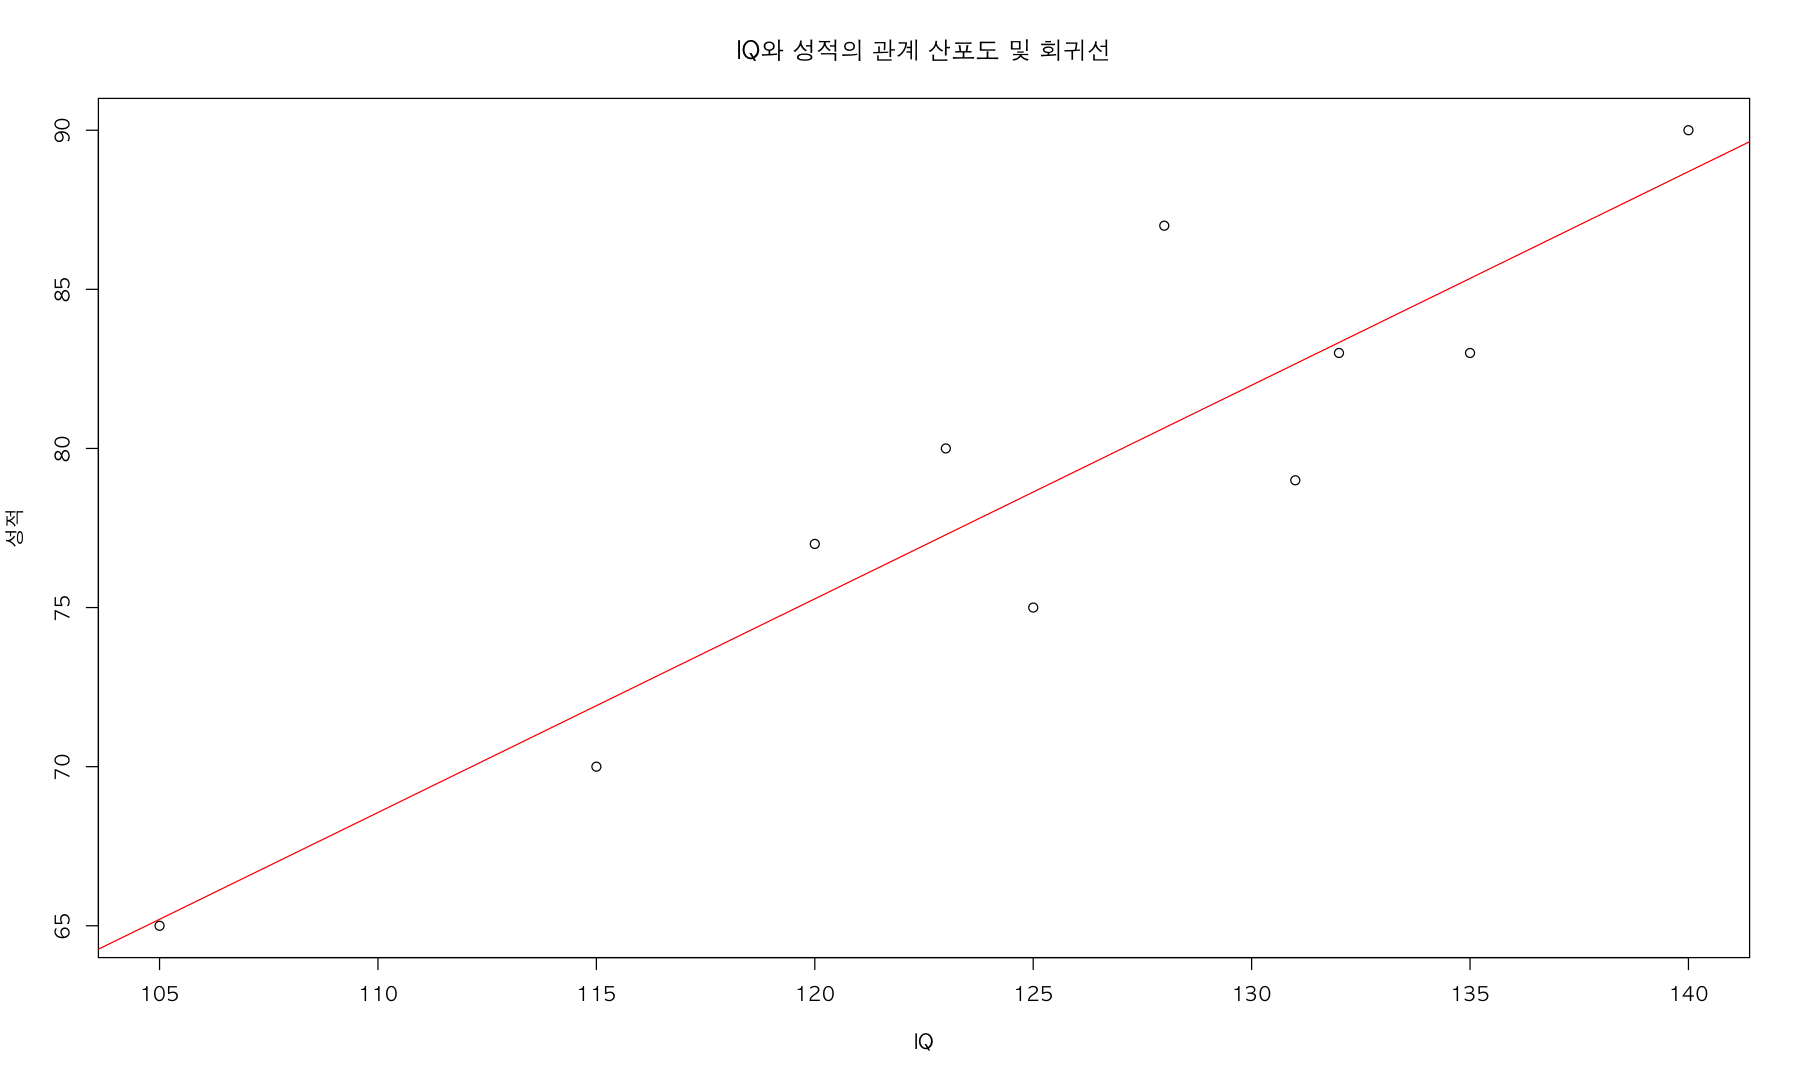

In [27]:
par(family = "AppleGothic", bg = 'white')
plot(
    iq$'성적' ~ iq$IQ,
    xlab = "IQ",
    ylab = '성적',
    main='IQ와 성적의 관계 산포도 및 회귀선'
)

r <- lm(iq$'성적' ~ iq$IQ)
abline(r, col = "red")

In [29]:
summary(r) # 절편은 쓰면 안된다 : IQ가 0인 사람은 없으니까


Call:
lm(formula = iq$성적 ~ iq$IQ)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.6598 -2.2384 -0.2674  1.6186  6.3544 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -5.2918    13.5832  -0.390 0.707007    
iq$IQ         0.6714     0.1080   6.217 0.000255 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.322 on 8 degrees of freedom
Multiple R-squared:  0.8285,	Adjusted R-squared:  0.8071 
F-statistic: 38.65 on 1 and 8 DF,  p-value: 0.0002547


In [30]:
paste(0.6714 * 126 - 3.322, "~", 0.6714 * 126 + 3.322)

[1] "81.2744 ~ 87.9184"

### (3) 학원을 몇군데 다녀야 성적이 90점 이상이 될까?

In [32]:
69.49 + 4.95 * 3

[1] 84.34

In [33]:
r


Call:
lm(formula = iq$성적 ~ iq$IQ)

Coefficients:
(Intercept)        iq$IQ  
    -5.2918       0.6714  


In [34]:
r <- lm(iq$다니는.학원수 ~ iq$성적)

In [35]:
r


Call:
lm(formula = iq$다니는.학원수 ~ iq$성적)

Coefficients:
(Intercept)      iq$성적  
    -7.8916       0.1241  


In [36]:
# IQ가 126인 사람의 성적?
0.1241   * 90 + (-7.8916)

[1] 3.2774

In [37]:
paste(0.6714 * 126 - 3.322, "~", 0.6714 * 126 + 3.322)

[1] "81.2744 ~ 87.9184"

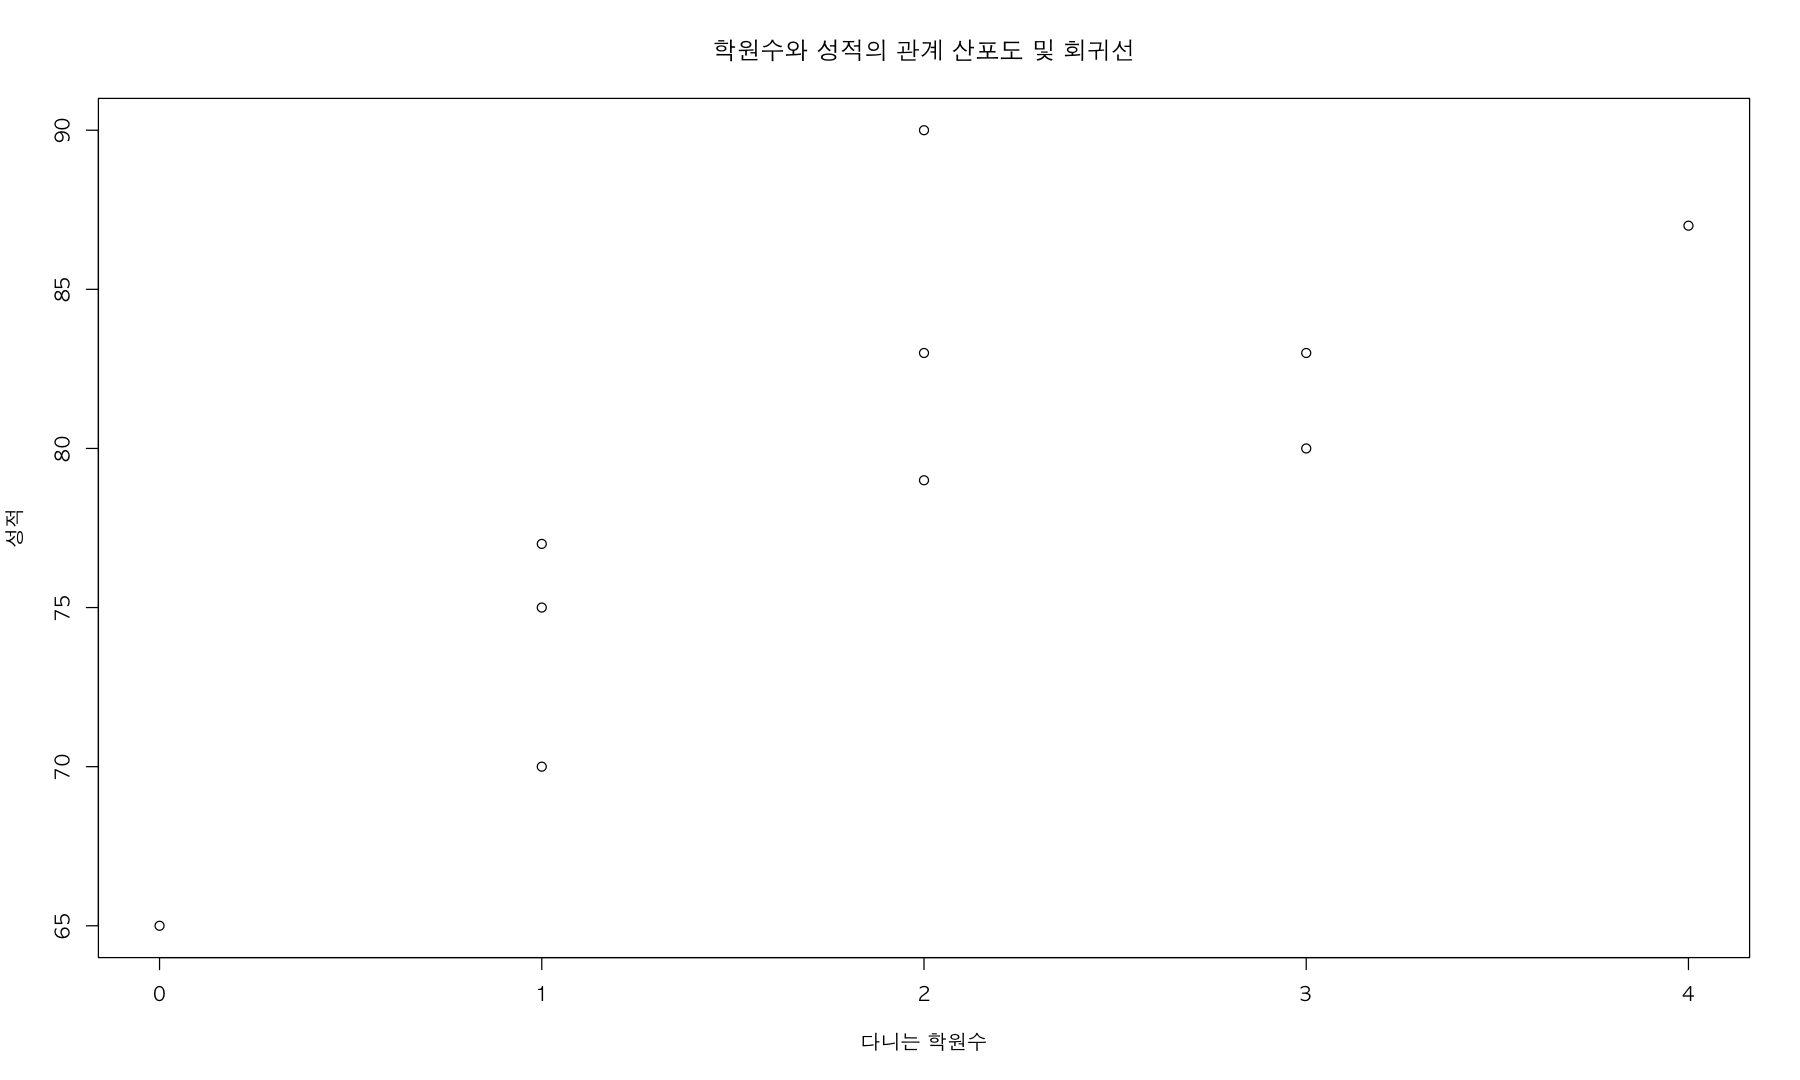

In [39]:
# 학원수와 성적의 관계 산포도
par(family = "AppleGothic", bg = 'white')
plot(
    iq$성적 ~ iq$다니는.학원수,
    xlab = '다니는 학원수',
    ylab = '성적',
    main = '학원수와 성적의 관계 산포도 및 회귀선'
)


In [40]:
# 회귀식 만들기
r <- lm(iq$성적 ~ iq$다니는.학원수)
r



Call:
lm(formula = iq$성적 ~ iq$다니는.학원수)

Coefficients:
     (Intercept)  iq$다니는.학원수  
          69.488             4.953  


In [41]:
# 회귀계수 확인하기
coef(r)


(Intercept) iq$다니는.학원수 
       69.488372         4.953488

In [42]:
# 성적이 90점이 되려면 필요한 학원수를 계산
(90 - 69.488372) / 4.953488


[1] 4.140845

In [43]:
# 정수로 바꾸기 위해 올림 처리
ceiling((90 - 69.488372) / 4.953488)


[1] 5

In [45]:
# 절편과 기울기를 이용해서 필요한 학원수 계산
(90 - coef(r)[1]) / coef(r)[2]


(Intercept) 
   4.140845

In [46]:
# 최소 몇 군데인지 확인
ceiling((90 - coef(r)[1]) / coef(r)[2])


(Intercept) 
          5

In [47]:
# 최종 결과 출력
paste("최소", ceiling((90 - coef(r)[1]) / coef(r)[2]), "군데")


[1] "최소 5 군데"

#### 다중 회귀 분석

In [48]:
# 여러개의 항목들로 구성된 식으로 에측하는 방법
data(attitude)

In [49]:
help(attitude)

attitude               package:datasets                R Documentation

_T_h_e _C_h_a_t_t_e_r_j_e_e-_P_r_i_c_e _A_t_t_i_t_u_d_e _D_a_t_a

_D_e_s_c_r_i_p_t_i_o_n:

     From a survey of the clerical employees of a large financial
     organization, the data are aggregated from the questionnaires of
     the approximately 35 employees for each of 30 (randomly selected)
     departments.  The numbers give the percent proportion of
     favourable responses to seven questions in each department.

_U_s_a_g_e:

     attitude
     
_F_o_r_m_a_t:

     A data frame with 30 observations on 7 variables. The first column
     are the short names from the reference, the second one the
     variable names in the data frame:

          Y  rating      numeric  Overall rating                    
       X[1]  complaints  numeric  Handling of employee complaints   
       X[2]  privileges  numeric  Does not allow special privileges 
       X[3]  learni

In [50]:
head(attitude)

,rating,complaints,privileges,learning,raises,critical,advance
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,43,51,30,39,61,92,45
2,63,64,51,54,63,73,47
3,71,70,68,69,76,86,48
4,61,63,45,47,54,84,35
5,81,78,56,66,71,83,47
6,43,55,49,44,54,49,34


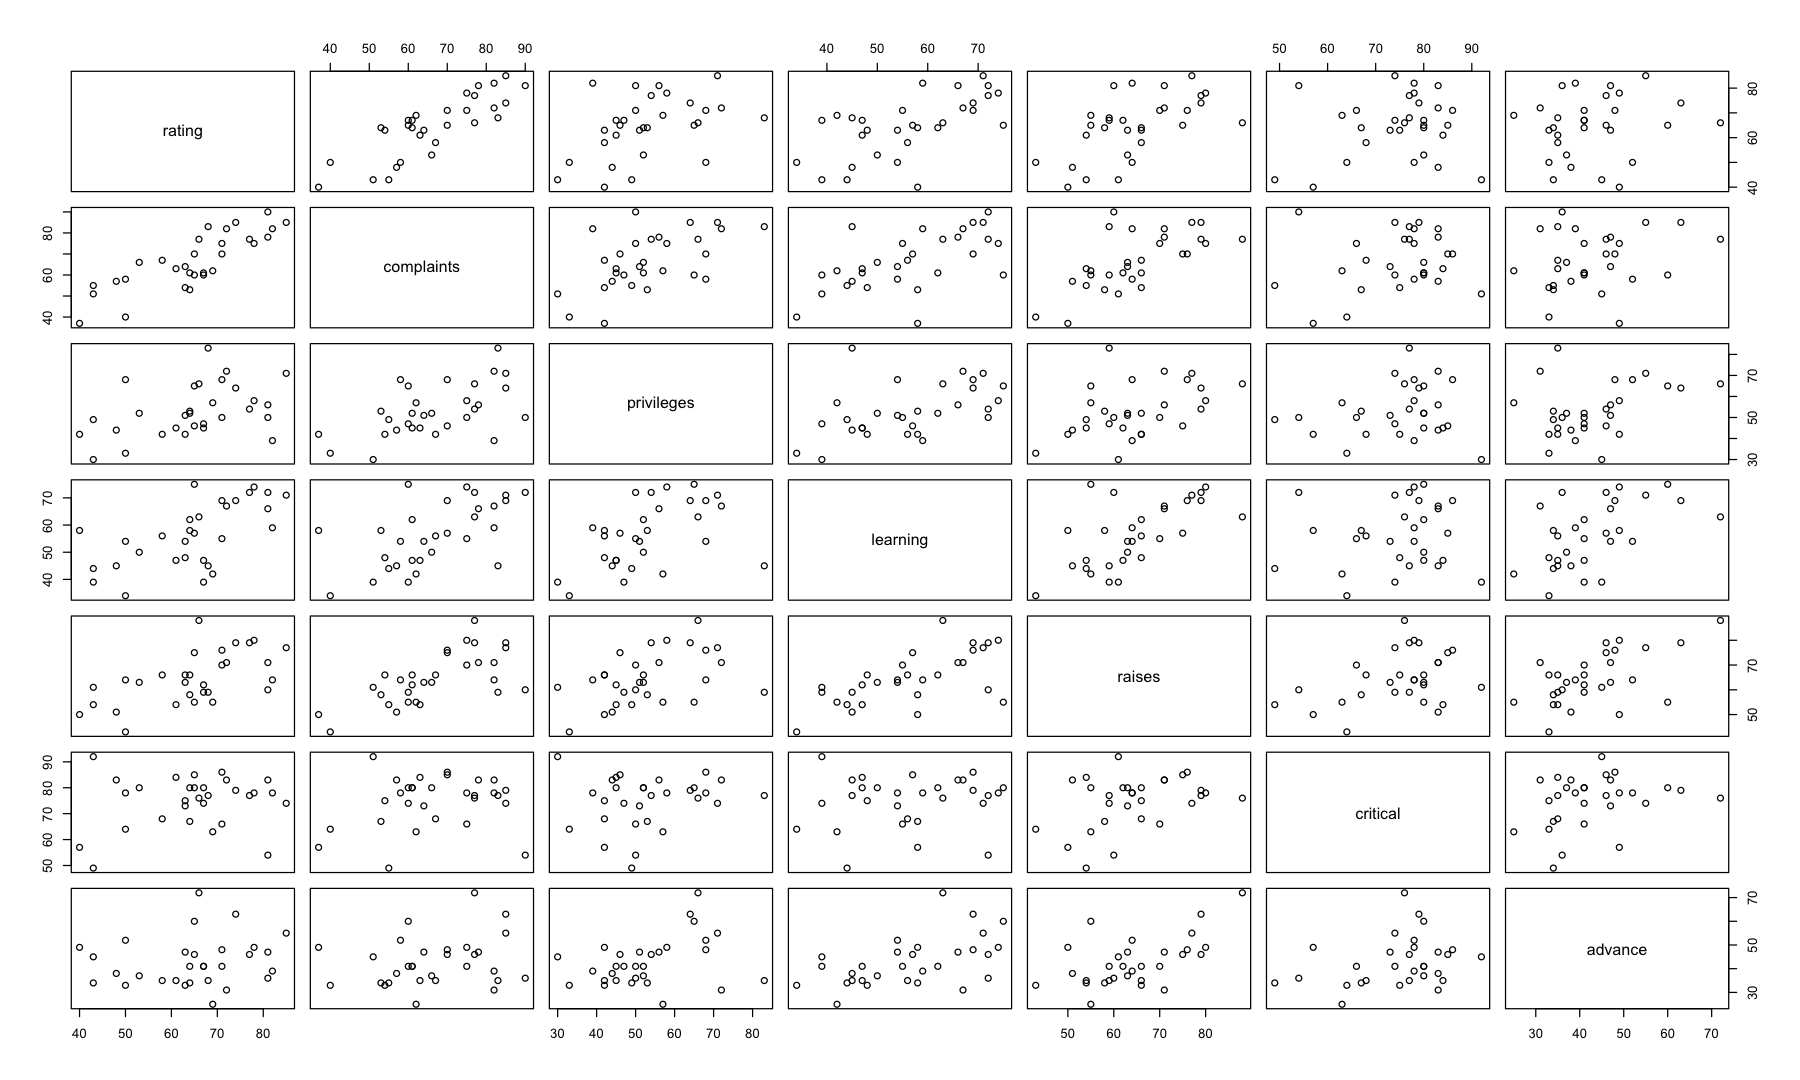

In [51]:
par(bg = 'white')
plot(attitude)

In [53]:
# rating을 제외한 변수들이 ratting에 미치는 영향 회귀분석
model <- lm(rating ~. , data = attitude)
model


Call:
lm(formula = rating ~ ., data = attitude)

Coefficients:
(Intercept)   complaints   privileges     learning       raises     critical  
   10.78708      0.61319     -0.07305      0.32033      0.08173      0.03838  
    advance  
   -0.21706  


In [61]:
summary(model) # 0.6628 이 다 합친 점수


Call:
lm(formula = rating ~ ., data = attitude)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.9418  -4.3555   0.3158   5.5425  11.5990 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 10.78708   11.58926   0.931 0.361634    
complaints   0.61319    0.16098   3.809 0.000903 ***
privileges  -0.07305    0.13572  -0.538 0.595594    
learning     0.32033    0.16852   1.901 0.069925 .  
raises       0.08173    0.22148   0.369 0.715480    
critical     0.03838    0.14700   0.261 0.796334    
advance     -0.21706    0.17821  -1.218 0.235577    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.068 on 23 degrees of freedom
Multiple R-squared:  0.7326,	Adjusted R-squared:  0.6628 
F-statistic:  10.5 on 6 and 23 DF,  p-value: 1.24e-05


In [58]:
cor(attitude)

,rating,complaints,privileges,learning,raises,critical,advance
rating,1.0000000,0.8254176,0.4261169,0.6236782,0.5901390,0.1564392,0.1550863
complaints,0.8254176,1.0000000,0.5582882,0.5967358,0.6691975,0.1877143,0.2245796
privileges,0.4261169,0.5582882,1.0000000,0.4933310,0.4454779,0.1472331,0.3432934
learning,0.6236782,0.5967358,0.4933310,1.0000000,0.6403144,0.1159652,0.5316198
raises,0.5901390,0.6691975,0.4454779,0.6403144,1.0000000,0.3768830,0.5741862
critical,0.1564392,0.1877143,0.1472331,0.1159652,0.3768830,1.0000000,0.2833432
advance,0.1550863,0.2245796,0.3432934,0.5316198,0.5741862,0.2833432,1.0000000


In [60]:
# 예측력을 높이기 위해 상대적으로 기여도가 낮은 변수를 제거
reduced <- step(model, direction = "backward") # direction_backward 는 낮은 거부터 제거하는 방법

Start:  AIC=123.36
rating ~ complaints + privileges + learning + raises + critical + 
    advance

             Df Sum of Sq    RSS    AIC
- critical    1      3.41 1152.4 121.45
- raises      1      6.80 1155.8 121.54
- privileges  1     14.47 1163.5 121.74
- advance     1     74.11 1223.1 123.24
<none>                    1149.0 123.36
- learning    1    180.50 1329.5 125.74
- complaints  1    724.80 1873.8 136.04

Step:  AIC=121.45
rating ~ complaints + privileges + learning + raises + advance

             Df Sum of Sq    RSS    AIC
- raises      1     10.61 1163.0 119.73
- privileges  1     14.16 1166.6 119.82
- advance     1     71.27 1223.7 121.25
<none>                    1152.4 121.45
- learning    1    177.74 1330.1 123.75
- complaints  1    724.70 1877.1 134.09

Step:  AIC=119.73
rating ~ complaints + privileges + learning + advance

             Df Sum of Sq    RSS    AIC
- privileges  1     16.10 1179.1 118.14
- advance     1     61.60 1224.6 119.28
<none>                  

In [62]:
summary(reduced)


Call:
lm(formula = rating ~ complaints + learning, data = attitude)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.5568  -5.7331   0.6701   6.5341  10.3610 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9.8709     7.0612   1.398    0.174    
complaints    0.6435     0.1185   5.432 9.57e-06 ***
learning      0.2112     0.1344   1.571    0.128    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.817 on 27 degrees of freedom
Multiple R-squared:  0.708,	Adjusted R-squared:  0.6864 
F-statistic: 32.74 on 2 and 27 DF,  p-value: 6.058e-08


In [63]:
# Complaints
model <- lm(rating~ complaints,data = attitude)
model 


Call:
lm(formula = rating ~ complaints, data = attitude)

Coefficients:
(Intercept)   complaints  
    14.3763       0.7546  


In [64]:
summary(model)


Call:
lm(formula = rating ~ complaints, data = attitude)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.8799  -5.9905   0.1783   6.2978   9.6294 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.37632    6.61999   2.172   0.0385 *  
complaints   0.75461    0.09753   7.737 1.99e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.993 on 28 degrees of freedom
Multiple R-squared:  0.6813,	Adjusted R-squared:  0.6699 
F-statistic: 59.86 on 1 and 28 DF,  p-value: 1.988e-08
